In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/project_1/customer_reviews_cleaned.csv')

In [4]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [5]:
import re

def clean_review(text):
    if pd.isna(text):
        return text

    # Fix 'wordbr nextword' → 'word. next word'
    text = re.sub(r'(\w)br\s+', r'\1. ', text)

    # Remove any remaining standalone 'br'
    text = re.sub(r'\bbr\b', '', text)

    # Fix multiple spaces
    text = re.sub(r' {2,}', ' ', text)

    return text.strip()

df['review_body_clean'] = df['review_body_clean'].apply(clean_review)
df['review_headline_clean'] = df['review_headline_clean'].apply(clean_review)

In [6]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment_label"] = df["star_rating"].apply(sentiment_label)

In [7]:
negative_df = df[df['sentiment_label'] == 'Negative'].copy()

complaint_dict = {
    'Device Performance Issues': ['slow','freeze','lag','crash','stuck','performance','device	'],
    'App Issues': ['app','apps','download','install','software'],
    'Screen Issues': ['screen','display','touchscreen','resolution'],
    'Battery Issues': ['battery','charge','charging','power'],
    'Delivery Issues': ['delivery','shipping','arrived','late'],
    'Packaging Issues': ['package','packaging','box'],
    'Durability Issues': ['broken','damage','damaged','durable','cracked'],
    'Price Issues': ['price','expensive','cost','worth']
}

In [8]:
def categorize_review(text):
    text = str(text).lower()

    for category, keywords in complaint_dict.items():
        if any(word in text for word in keywords):
            return category

    return 'Other Complaints'

negative_df['Complaint_Category'] = negative_df['review_body_clean'].apply(categorize_review)

#Complaint Category Performance

In [9]:
complaint_summary = (
    negative_df
    .groupby('Complaint_Category')
    .agg(
        Complaints=('Complaint_Category','count'),
        Avg_Rating=('star_rating','mean')
    )
    .sort_values('Complaints', ascending=False)
)

complaint_summary

,Complaints,Avg_Rating
Complaint_Category,,
App Issues,1054,1.434535
Other Complaints,970,1.355670
Device Performance Issues,326,1.475460
Battery Issues,238,1.386555
Screen Issues,139,1.402878
Delivery Issues,54,1.259259
Price Issues,52,1.423077
Packaging Issues,16,1.500000
Durability Issues,12,1.333333


<Axes: xlabel='Complaints', ylabel='Complaint_Category'>

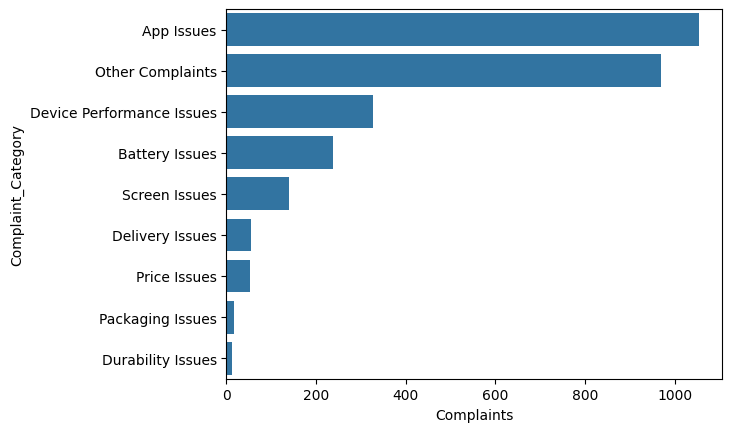

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(
    data=complaint_summary.reset_index(),
    x='Complaints',
    y='Complaint_Category'
)

#Product Satisfaction Ranking

In [10]:
product_performance = (
    df.groupby('seller_id')
      .agg(
          Reviews=('seller_id','count'),
          Avg_Rating=('star_rating','mean')
      )
      .query('Reviews > 100')
      .sort_values('Avg_Rating', ascending=False)
)

product_performance.head(10)

,Reviews,Avg_Rating
seller_id,,
seller_13,1755,4.516239
seller_21,148,4.513514
seller_20,1160,4.494828
seller_11,207,4.487923
seller_14,1126,4.475133
seller_16,609,4.463054
seller_15,1759,4.445139
seller_18,824,4.425971
seller_1,6271,4.355765


<Axes: xlabel='Avg_Rating', ylabel='seller_id'>

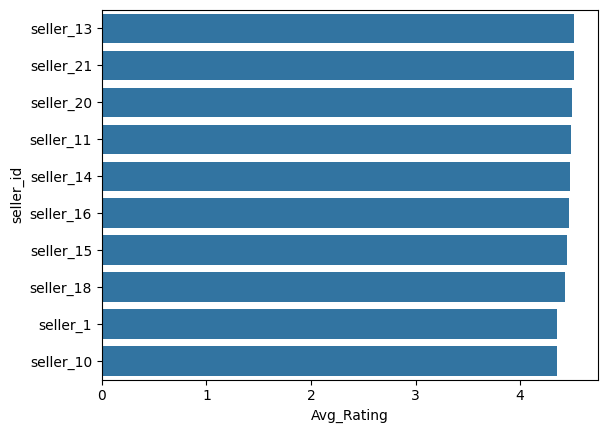

In [ ]:
top_products = product_performance.head(10)

sns.barplot(
    data=top_products.reset_index(),
    x='Avg_Rating',
    y='seller_id'
)

#Product Complaint Analysis

In [11]:
product_complaints = (
    negative_df
    .groupby('seller_id')
    .size()
    .reset_index(name='Negative_Reviews')
    .sort_values('Negative_Reviews', ascending=False)
)

product_complaints.head(10)

,seller_id,Negative_Reviews
14,seller_3,1374
0,seller_1,529
15,seller_4,233
6,seller_15,112
4,seller_13,105
16,seller_5,76
12,seller_20,76
20,seller_9,69
5,seller_14,67
9,seller_18,62


/tmp/ipykernel_9481/1494016934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


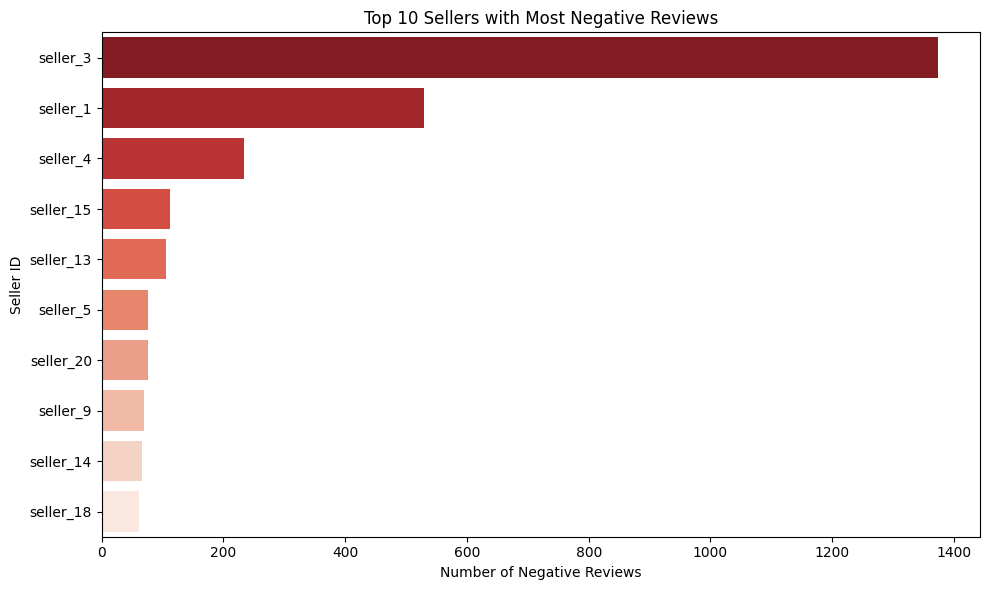

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_complaints.head(10),
    x='Negative_Reviews',
    y='seller_id',
    palette='Reds_r'
)

plt.title('Top 10 Sellers with Most Negative Reviews')
plt.xlabel('Number of Negative Reviews')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()

#Seller Risk Metrics

In [12]:
# Total reviews per seller
seller_reviews = df.groupby('seller_id').size().reset_index(name='Total_Reviews')

# Average rating
avg_rating = df.groupby('seller_id')['star_rating'].mean().reset_index(name='Avg_Rating')

# Negative reviews
negative_reviews = (
    df[df['sentiment_label'] == 'Negative']
    .groupby('seller_id')
    .size()
    .reset_index(name='Negative_Reviews')
)

# Merge
seller_risk = seller_reviews.merge(avg_rating,on='seller_id')
seller_risk = seller_risk.merge(
    negative_reviews,
    on='seller_id',
    how='left'
)

seller_risk['Negative_Reviews'] = seller_risk['Negative_Reviews'].fillna(0)

# Negative %
seller_risk['Negative_Percent'] = (
    seller_risk['Negative_Reviews']
    / seller_risk['Total_Reviews']
) * 100

seller_risk.head()

,seller_id,Total_Reviews,Avg_Rating,Negative_Reviews,Negative_Percent
0,seller_1,6271,4.355765,529,8.435656
1,seller_10,138,4.355072,11,7.971014
2,seller_11,207,4.487923,12,5.797101
3,seller_12,137,4.313869,11,8.029197
4,seller_13,1755,4.516239,105,5.982906


#Risk Classification

In [13]:
def classify_seller(row):

    if row['Avg_Rating'] >= 4.3 and row['Negative_Percent'] < 15:
        return 'Best Performer'

    elif row['Avg_Rating'] < 4.3 and row['Negative_Percent'] >= 15:
        return 'High Risk'

    elif row['Avg_Rating'] >= 4.3 and row['Negative_Percent'] >= 15:
        return 'Monitor'

    else:
        return 'Watchlist'


seller_risk['Risk_Category'] = seller_risk.apply(
    classify_seller,
    axis=1
)

seller_risk.head()

,seller_id,Total_Reviews,Avg_Rating,Negative_Reviews,Negative_Percent,Risk_Category
0,seller_1,6271,4.355765,529,8.435656,Best Performer
1,seller_10,138,4.355072,11,7.971014,Best Performer
2,seller_11,207,4.487923,12,5.797101,Best Performer
3,seller_12,137,4.313869,11,8.029197,Best Performer
4,seller_13,1755,4.516239,105,5.982906,Best Performer


In [33]:
!pip install adjustText

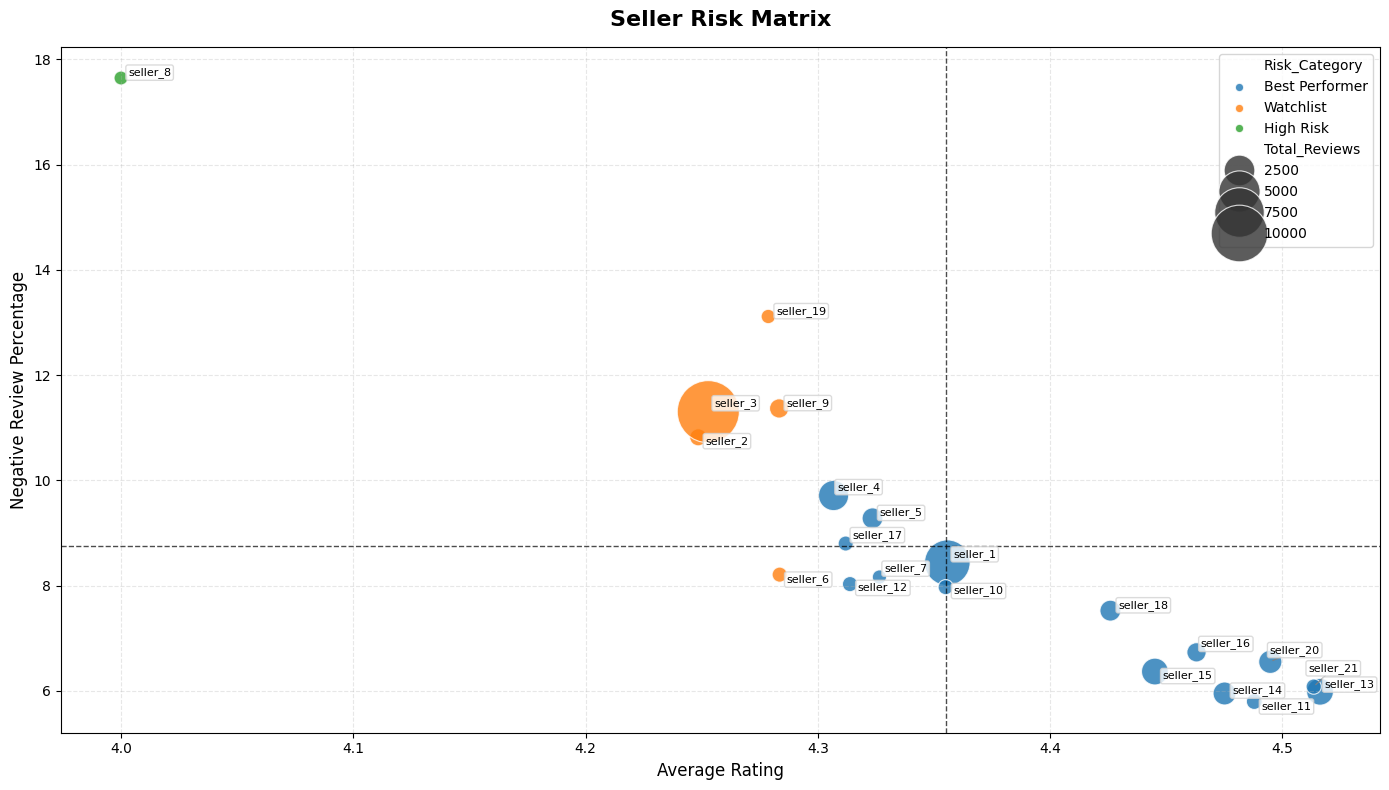

In [34]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Seller Risk Matrix
# -----------------------------

plt.style.use('default')

fig, ax = plt.subplots(figsize=(14, 8))

# Background styling
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Scatter plot
sns.scatterplot(
    data=seller_risk,
    x='Avg_Rating',
    y='Negative_Percent',
    size='Total_Reviews',
    hue='Risk_Category',
    sizes=(100, 2000),
    alpha=0.8,
    ax=ax
)

# Create labels
texts = []

for _, row in seller_risk.iterrows():
    texts.append(
        ax.text(
            row['Avg_Rating'],
            row['Negative_Percent'],
            str(row['seller_id']),
            fontsize=8,
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                edgecolor='lightgray',
                alpha=0.8
            )
        )
    )

# Automatically move labels and draw connector lines
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=0.8
    ),
    ax=ax
)

# Quadrant reference lines
ax.axvline(
    seller_risk['Avg_Rating'].mean(),
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)

ax.axhline(
    seller_risk['Negative_Percent'].mean(),
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)

# Titles and labels
ax.set_title(
    'Seller Risk Matrix',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Average Rating',
    fontsize=12
)

ax.set_ylabel(
    'Negative Review Percentage',
    fontsize=12
)

# Optional grid
ax.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

Top risky sellers

In [30]:
seller_risk.sort_values(
    ['Negative_Percent','Total_Reviews'],
    ascending=[False,False]
).head(5)

,seller_id,Total_Reviews,Avg_Rating,Negative_Reviews,Negative_Percent,Risk_Category
19,seller_8,17,4.000000,3,17.647059,High Risk
10,seller_19,61,4.278689,8,13.114754,Watchlist
20,seller_9,607,4.283361,69,11.367381,Watchlist
14,seller_3,12153,4.252859,1374,11.305850,Watchlist
11,seller_2,342,4.248538,37,10.818713,Watchlist


Best sellers:

In [31]:
seller_risk.sort_values(
    ['Avg_Rating','Total_Reviews'],
    ascending=[False,False]
).head(5)

,seller_id,Total_Reviews,Avg_Rating,Negative_Reviews,Negative_Percent,Risk_Category
4,seller_13,1755,4.516239,105,5.982906,Best Performer
13,seller_21,148,4.513514,9,6.081081,Best Performer
12,seller_20,1160,4.494828,76,6.551724,Best Performer
2,seller_11,207,4.487923,12,5.797101,Best Performer
5,seller_14,1126,4.475133,67,5.950266,Best Performer


##Short Insights
* Seller_13 is the best-performing seller, achieving the highest average rating (4.52) with low negative feedback.
* Seller_3 is the primary risk area, generating 1,374 negative reviews and contributing the largest share of customer dissatisfaction.
* Most sellers maintain strong performance, with average ratings above 4.3 and relatively low negative review rates.
* Seller volume is a key risk driver, making Seller_3 more impactful than smaller sellers with higher negative percentages.

##Main Insights:

* **Seller_13** is the top-performing seller with the highest average rating (4.52).

* **Seller_3** is the highest-priority improvement area, generating 1,374 negative reviews and nearly 39% of all customer feedback.

#Key Insights
1. App Issues are the biggest problem, generating 1,054 complaints (36.8%), making them the top improvement area.
2. Seller_13 is the best-performing seller, achieving the highest average rating of 4.52 from 1,755 reviews.
3. Seller_3 is the biggest concern, receiving 1,374 negative reviews, nearly half of all negative feedback despite being the highest-volume seller.
4. Device Performance (326 complaints) and Battery Issues (238 complaints) are major product-related concerns and together account for 564 complaints.
5. Delivery Issues have the lowest customer rating (1.26), showing that customers are highly dissatisfied when delivery problems occur.

---

#Recommendations
1. **Prioritize App Improvements**
   - Address app crashes, bugs, and usability issues.
   - Potentially reduce over 1,000 customer complaints.

2. **Investigate Seller_3**
   - Review product quality, customer support, and complaint drivers.
   - Reducing Seller_3 complaints will significantly improve overall satisfaction.
3. **Apply Seller_13 Best Practices**
    - Use Seller_13 as a benchmark for quality and customer experience.
4. **Improve Product Reliability**
    - Focus on device performance and battery optimization to address 564 complaints.
5. **Enhance Delivery Operations**
    - Improve shipping communication and tracking to reduce the most severe customer dissatisfaction area.